# Custom State

We use TypedDict to define a custom state.

In [2]:
from typing import TypedDict, NotRequired

class State(TypedDict):
    user_name: NotRequired[str]
    user_age: NotRequired[int]

state: State = {}
user_name = state.get("user_name", None)

# Nodes

We can use nodes to execute a task, nodes are a python fuction. We have to return an update of the state.

In [3]:
def node_1(state: State):
    if state.get("user_name") is None:
        return {
            "user_name": "Yael"
        }
    return {}

# Graph

Define the structure.

In [4]:
from langgraph.graph import StateGraph, START, END

# Intialize using the custom state
builder = StateGraph(State)
# Add the node
builder.add_node("node_1", node_1)
# Defin the conections between nodes using the START and END node
builder.add_edge(START, 'node_1')
builder.add_edge('node_1', END)
# Compile the Graph
agent = builder.compile()

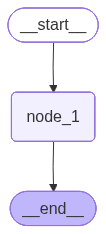

In [5]:
from IPython.display import Image, display

display(Image(agent.get_graph().draw_mermaid_png()))